In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

import torch_geometric



In [26]:
data_dir = 'rr_data/'

os.listdir(data_dir)
data = [pd.read_csv(os.path.join(data_dir, file)) for file in os.listdir(data_dir)]

In [27]:
events = data[1]
prop1 = data[2]
prop2 = data[3]


In [28]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [29]:
prop1.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [30]:
prop2.head()

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


In [31]:
from datetime import datetime

import datetime

def unix_to_datetime(timestamp):
    try:
        # If timestamp is in milliseconds, convert to seconds
        if timestamp > 1e12:
            timestamp /= 1000
        dt_object = datetime.datetime.fromtimestamp(timestamp)
        return dt_object
    except (OSError, OverflowError, ValueError) as e:
        print(f"Invalid timestamp: {e}")
        return None

#[unix_to_datetime(timestamp) for timestamp in events['timestamp'].head()]
events['datetime'] = [unix_to_datetime(timestamp) for timestamp in events['timestamp']]

#datetime.fromtimestamp()

In [ ]:
events.head()

events['month'] = events['datetime'].dt.month
events['date'] = events['datetime'].dt.date
events =events.sort_values('datetime').reset_index(drop=True)

<Axes: xlabel='date'>

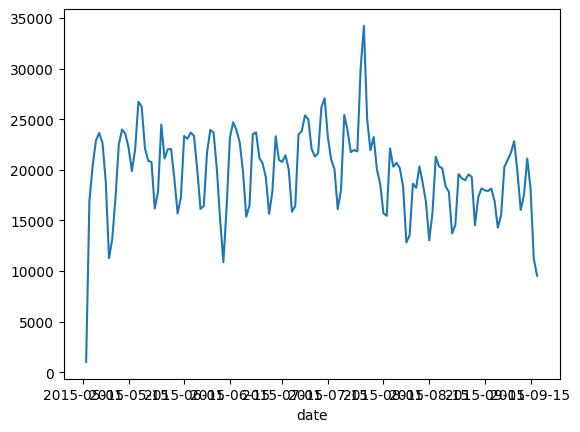

In [ ]:
# plot daily number of sales

events['date'].value_counts().sort_index().plot(kind='line')


<Axes: >

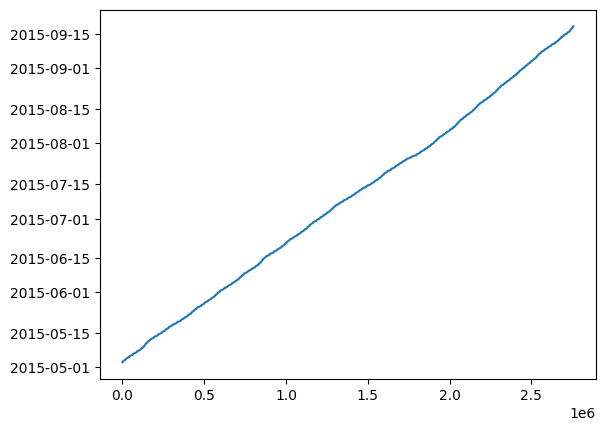

In [43]:
events['datetime'].plot(kind='line')

In [41]:
events

,timestamp,visitorid,event,itemid,transactionid,datetime,month,date
1462974,1430622004384,693516,addtocart,297662,NaN,2015-05-02 23:00:04.384,5,2015-05-02
1464806,1430622011289,829044,view,60987,NaN,2015-05-02 23:00:11.289,5,2015-05-02
1463000,1430622013048,652699,view,252860,NaN,2015-05-02 23:00:13.048,5,2015-05-02
1465287,1430622024154,1125936,view,33661,NaN,2015-05-02 23:00:24.154,5,2015-05-02
1462955,1430622026228,693516,view,297662,NaN,2015-05-02 23:00:26.228,5,2015-05-02
...,...,...,...,...,...,...,...,...
1461164,1442545164029,472345,view,301436,NaN,2015-09-17 22:59:24.029,9,2015-09-17
1456543,1442545165499,1207677,view,310922,NaN,2015-09-17 22:59:25.499,9,2015-09-17
1456783,1442545174109,255126,view,47467,NaN,2015-09-17 22:59:34.109,9,2015-09-17
1454122,1442545181778,622226,view,345308,NaN,2015-09-17 22:59:41.778,9,2015-09-17


In [44]:
events['visitorid'].unique().shape

(1407580,)

In [ ]:
print(np.max(events['visitorid']))
print(np.min(events['visitorid']))
# the indexing is dense for visitors

print(events['itemid'].unique().shape)
print(np.min(events['itemid']))
print(np.max(events['itemid'])) 
# not for items.

1407579
0
(235061,)
3
466867


In [ ]:
events['itemid'].unique()

(235061,)

In [ ]:
views = events.query("event == 'view'")[['visitorid', 'itemid']]
add_to_carts = events.query("event == 'addtocart'")[['visitorid', 'itemid']]

purchases = events.query("event == 'transaction'")[['visitorid', 'itemid', 'transactionid']]

In [58]:
for df in [views, add_to_carts, purchases]:
    print(df.shape)

(2664312, 2)
(69332, 2)
(22457, 3)


In [56]:
events['event'].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [ ]:

from torch_geometric.data import HeteroData

import torch

graph_data = HeteroData()

graph_data['visitor'].x = torch.tensor(events['visitorid'].unique())
graph_data['item'].x = torch.tensor(events['itemid'].unique())

graph_data['visitor', 'viewed', 'item'].edge_index = torch.tensor([views['visitorid'].values ,views['itemid'].values], dtype=torch.long) 
graph_data['visitor', 'added_to_cart', 'item'].edge_index = torch.tensor([add_to_carts['visitorid'].values ,add_to_carts['itemid'].values], dtype=torch.long)
graph_data['visitor', 'purchased', 'item'].edge_index = torch.tensor([purchases['visitorid'].values ,purchases['itemid'].values], dtype=torch.long)

print(graph_data.num_edges)




2756101


In [60]:
print(graph_data.num_nodes)

1642641
